In [107]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')  # hides warnings

# Preparamos el Dataset de Años de Experiencia vs Salario

In [108]:
df = pd.read_csv(r"C:\Users\felip\Desktop\ML Projects\linear-regression-from-scratch\data\Salary_Data.csv")

In [109]:
df.columns

Index(['YearsExperience', 'Salary'], dtype='object')

# Regresión lineal (Gradient descent)

In [ ]:
# Mean square error function

def mse(m, b, points):
    total_error = 0

    for i in range(len(points)):
        x = points.iloc[i].YearsExperience
        y = points.iloc[i].Salary
        total_error += (y - (m * x + b)) ** 2
    
    return total_error / float(len(points))

In [ ]:
# Gradient descent function

def gradient_descent(m_now, b_now, points, L):
    m_gradient = 0.0
    b_gradient = 0.0

    n = len(points)

    for i in range(n):
        x = points.iloc[i].YearsExperience
        y = points.iloc[i].Salary

        m_gradient += -(2/n) * x * (y - (m_now * x + b_now))
        b_gradient += -(2/n) * (y - (m_now * x + b_now))

    m = m_now - m_gradient * L
    b = b_now - b_gradient * L

    return m, b

In [ ]:
m = 0
b = 0
L = 0.0001
epochs = 1000     # Iterations

for i in range(epochs):
    if i % 50 == 0:
        error = mse(m, b, df)
        print(f"Epoch: {i} - MSE: {error} - RMSE: {np.sqrt(error)}")
    m, b = gradient_descent(m, b, df, L)

print(m, b)


Epoch: 0 - MSE: 6502955270.733334
Epoch: 50 - MSE: 3186417688.139748
Epoch: 100 - MSE: 1601922538.1839087
Epoch: 150 - MSE: 844781253.8180302
Epoch: 200 - MSE: 482847053.3942722
Epoch: 250 - MSE: 309694377.95203674
Epoch: 300 - MSE: 226718970.16071856
Epoch: 350 - MSE: 186820073.11002606
Epoch: 400 - MSE: 167498845.43479875
Epoch: 450 - MSE: 158008156.70377895
Epoch: 500 - MSE: 153214370.68190596
Epoch: 550 - MSE: 150665274.91902527
Epoch: 600 - MSE: 149189505.09992513
Epoch: 650 - MSE: 148227525.58837655
Epoch: 700 - MSE: 147512055.80572623
Epoch: 750 - MSE: 146915418.01933834
Epoch: 800 - MSE: 146376619.25378403
Epoch: 850 - MSE: 145866520.1696412
Epoch: 900 - MSE: 145371197.1204689
Epoch: 950 - MSE: 144883994.62944233
12836.600965885045 2915.204485601402


In [ ]:
# Alternative code to seek for a better MSE
    # Lower L and higher number of Epochs

m = 0
b = 0
L = 0.00001
epochs = 10000 

for i in range(epochs):
    m, b = gradient_descent(m, b, df, L)
    if i % 100 == 0:
        error = mse(m, b, df)
        print(f"Epoch {i} - MSE: {error} - RMSE: {np.sqrt(error)}")

print(m, b)

Epoch 0 - MSE: 6493611271.69961
Epoch 100 - MSE: 5625393405.452043
Epoch 200 - MSE: 4876057909.031199
Epoch 300 - MSE: 4229324661.1913824
Epoch 400 - MSE: 3671142992.7248483
Epoch 500 - MSE: 3189386378.145169
Epoch 600 - MSE: 2773588937.271255
Epoch 700 - MSE: 2414718021.1300683
Epoch 800 - MSE: 2104977940.675591
Epoch 900 - MSE: 1837640573.526903
Epoch 1000 - MSE: 1606899167.9631193
Epoch 1100 - MSE: 1407742167.4684434
Epoch 1200 - MSE: 1235844314.148917
Epoch 1300 - MSE: 1087472664.7967465
Epoch 1400 - MSE: 959405477.4163914
Epoch 1500 - MSE: 848862205.6900586
Epoch 1600 - MSE: 753443080.2257603
Epoch 1700 - MSE: 671076963.7431443
Epoch 1800 - MSE: 599976347.1375176
Epoch 1900 - MSE: 538598508.5272892
Epoch 2000 - MSE: 485611991.30610186
Epoch 2100 - MSE: 439867672.7980674
Epoch 2200 - MSE: 400373794.86420816
Epoch 2300 - MSE: 366274413.8977905
Epoch 2400 - MSE: 336830801.94643646
Epoch 2500 - MSE: 311405394.82426643
Epoch 2600 - MSE: 289447938.4210804
Epoch 2700 - MSE: 270483532.180

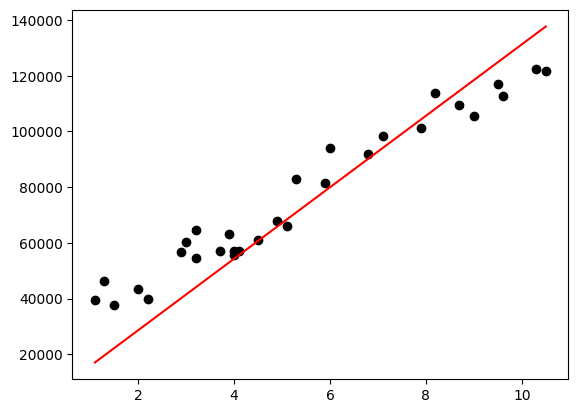

In [114]:
x_min = df["YearsExperience"].min()
x_max = df["YearsExperience"].max()

x_line = np.linspace(x_min, x_max, 100)     # 100 puntos entre min y max
y_line = m * x_line + b

plt.scatter(df.YearsExperience, df.Salary, color="black")
plt.plot(x_line, y_line, color="red")

plt.show()

# Interpretación del modelo

<p style="text-align: center;">Salary = 12836 * YearsExperience + 2915</p>

- Por cada 1 año extra de experiencia, el salario sube $12.836
- Cuando experiencia = 0, predice un salario base ~$2.915 (no siempre realista, pero matemáticamente es el intercepto).

# Bonus

## Entrenemos y testiemos con scikit-learn

In [116]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)


In [ ]:
m, b = 0, 0

for _ in range(epochs):
    m, b = gradient_descent(m, b, train_df, L)

test_error = mse(m, b, test_df)
print("Test MSE:", test_error, "- Test RMSE: ", np.sqrt(test_error))

Test MSE: 141154431.30218396 Test RMSE:  11880.843038361543


## Gráficamos errores

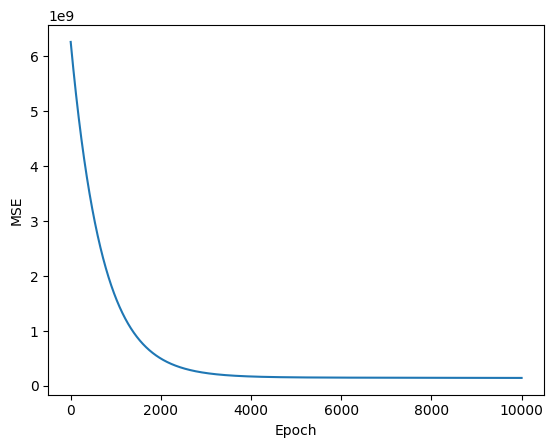

In [118]:
errors = []

m, b = 0, 0
for i in range(epochs):
    m, b = gradient_descent(m, b, train_df, L)
    errors.append(mse(m, b, train_df))

plt.plot(errors)
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.show()

Observaciones:

- Después de las 4000 - 5000 repeticiones (Epochs) se disminuye muy poco el error por seguir entrenando. Por lo tanto, el uso de más de 6000 Epochs no se justifica debido a mejoras marginales.

# Notas sobre MSE y RMSE

El MSE tiene dos “problemas” prácticos:

1) Las unidades están al cuadrado

En este caso:

- Salary está en dinero

- MSE está en dinero²

2) Magnifica visualmente los números

Como se eleva al cuadrado:

- errores grandes dominan el valor

- los números se ven gigantes

## Por qué RMSE sí es útil

**RMSE devuelve el error a la misma unidad que el target.**

Ejemplo real:

<p style="text-align: center;">RMSE ≈ 11,900</p>

Interpretación directa:

<p style="text-align: center;">“En promedio, el modelo se equivoca en unos 11.9k de salario.”</p>

## Cuándo usar MSE y cuándo RMSE

| Métrica | Útil para                                      |
| ------- | ---------------------------------------------- |
| MSE     | Optimización matemática (gradient descent)     |
| RMSE    | Interpretación humana y comparación de modelos |


Por eso:

- Entrenar con MSE

- Evalúar y comunicar con RMSE